<div style="border-radius:10px; border:#808080 solid; padding: 15px; background-color:##F0E68C ; font-size:100%; text-align:left">

## 📊 Dataset Overview: NFL Draft Prediction

### Dataset Summary
- **Number of rows**: 2781 Player.
- **Number of columns**: 15 features + 1 Target variable.
- **Target Variable**: Drafted (0,1).


### 🔍 Objective

the Goal of this project is to predict whether a player was Drafted or not using multiple models.

### ✅ Dataset characteristics

- **No duplicates**.
- **Missing values**: Missing values exist in **Age** , **sprint_40yd** , **Vertical_Jump** , **Bench_Press_Reps** , **Broad_Jump**, **Agility_3cone** , **Shuttle**.
- Mix of **categorical** and **numerical** data types.
- Variables represent Player: **athletic ability** , **college performance**, **playing position** and More.

### 🧾 Feature List

| Column Name        | Description                        |
|--------------------|------------------------------------|
| `Year`             | The year the record corresponds to |
| `Age`              | Player age                         |
| `School`           | Player School                      |
| `Height`           | Player Height in `cm's`            |
| `Weight`           | Player Weight in `Kg's`            |
| `Sprint_40yd`      | 40-yard dash time                  |
| `Vertical_Jump`    |Vertical jump reach                 |
| `Bench_Press_Reps` |Number of bench press repetitions   |
| `Broad_Jump`       |Broad jump distance                 |
| `Agility_3cone`    |3-cone drill time                   |
| `Shuttle`          |20-yard shuttle time                |
| `Player_Type`      |Broad role category (offense, defense, special teams)              |
| `Position_Type`    |Position type                       |
| `Position`         |Specific position                   |
| `Drafted`          |Whether the player was drafted      |

# __1.Setup__

In [1484]:
# %pip install optuna

In [1485]:
# %pip install catboost

In [1486]:
#Import modules and libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek
from sklearn.model_selection import StratifiedGroupKFold,cross_val_score
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

import optuna

# __2.Data Loading__

In [1487]:
from google.colab import drive
drive.mount('/content/drive')
%cd '/content/drive/MyDrive/MyGci/MayCompetetion/competition'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/MyGci/MayCompetetion/competition


In [1488]:
train_df = pd.read_csv("/content/drive/MyDrive/MyGci/MayCompetetion/competition/input/train.csv")
X_test = pd.read_csv("/content/drive/MyDrive/MyGci/MayCompetetion/competition/input/test.csv")
print(f"Train: {train_df.shape}\nTest: {X_test.shape}")

Train: (2781, 16)
Test: (696, 15)


# __3.Data Overview__

In [1489]:
train_df = train_df.drop("Id",axis=1) #also drop the school column as it has 100s of value_counts

In [1490]:
train_df.head()

,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,offense,offensive_lineman,OG,1.0
1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,NaN,NaN,offense,backs_receivers,WR,1.0
2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,offense,backs_receivers,WR,1.0
3,2010,21.0,East Carolina,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,defense,defensive_lineman,DT,1.0
4,2016,21.0,California,1.8796,92.079251,4.64,78.74,NaN,281.94,7.13,4.20,offense,backs_receivers,WR,1.0


In [1491]:
train_df.info() # 15cols, nulls exists, some obj cols

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2781 entries, 0 to 2780
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              2781 non-null   int64  
 1   Age               2346 non-null   float64
 2   School            2781 non-null   object 
 3   Height            2781 non-null   float64
 4   Weight            2781 non-null   float64
 5   Sprint_40yd       2636 non-null   float64
 6   Vertical_Jump     2227 non-null   float64
 7   Bench_Press_Reps  2060 non-null   float64
 8   Broad_Jump        2200 non-null   float64
 9   Agility_3cone     1811 non-null   float64
 10  Shuttle           1869 non-null   float64
 11  Player_Type       2781 non-null   object 
 12  Position_Type     2781 non-null   object 
 13  Position          2781 non-null   object 
 14  Drafted           2781 non-null   float64
dtypes: float64(10), int64(1), object(4)
memory usage: 326.0+ KB


In [1492]:
train_df.describe()
# min vs max --> outliers, scaling, range
# mean vs median --> skewness
# std --> spread check(clustring)
# count --> missing data

,Year,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Drafted
count,2781.000000,2346.000000,2781.000000,2781.000000,2636.000000,2227.000000,2060.000000,2200.000000,1811.000000,1869.000000,2781.000000
mean,2013.838907,21.997016,1.873590,109.502026,4.764818,83.506349,20.236408,291.985700,7.230447,4.399422,0.648328
std,3.083247,0.964836,0.067178,20.307239,0.299343,10.710691,6.410662,23.924666,0.410686,0.263851,0.477578
min,2009.000000,18.000000,1.651000,67.585263,4.220000,44.450000,2.000000,198.120000,6.280000,3.820000,0.000000
25%,2011.000000,21.000000,1.828800,92.986436,4.530000,76.200000,16.000000,276.860000,6.930000,4.200000,0.000000
50%,2014.000000,22.000000,1.879600,104.779837,4.680000,83.820000,20.000000,294.640000,7.130000,4.350000,1.000000
75%,2017.000000,23.000000,1.930400,124.284309,4.950000,91.440000,24.000000,307.340000,7.490000,4.560000,1.000000
max,2019.000000,28.000000,2.082800,162.386068,6.000000,114.300000,45.000000,373.380000,9.040000,5.560000,1.000000


In [1493]:
train_df.isna().sum() #needs to be filled so i will try mean,median for baseline then imputers
# for this specific dataset missing a drill is an indicator

,0
Year,0
Age,435
School,0
Height,0
Weight,0
Sprint_40yd,145
Vertical_Jump,554
Bench_Press_Reps,721
Broad_Jump,581
Agility_3cone,970


In [1494]:
train_df.duplicated().sum() #no dups

np.int64(0)

In [1495]:
train_df['Age'].value_counts()

,count
Age,
22.0,968
21.0,585
23.0,580
20.0,112
24.0,83
25.0,10
26.0,6
18.0,1
28.0,1


In [1496]:
X = train_df.drop('Drafted',axis=1)
y = train_df['Drafted']

In [1497]:
X_train,X_valid,y_train,y_valid = train_test_split(X,y,test_size=.2,random_state=42,stratify=y)

# __4.EDA__

## Univariate analysis

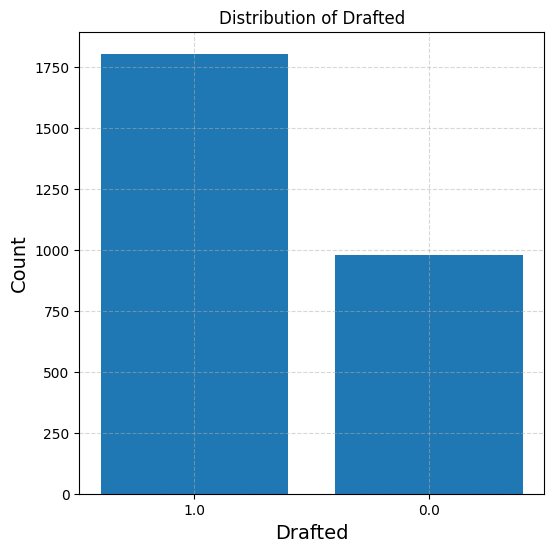

In [1498]:
drafted_counts = train_df['Drafted'].value_counts()

plt.figure(figsize=(6,6))
plt.bar(drafted_counts.index.astype(str),drafted_counts.values)
plt.title("Distribution of Drafted")
plt.xlabel("Drafted",fontsize=14)
plt.ylabel("Count",fontsize=14)

plt.grid(True, linestyle='--', alpha=.5)
plt.show()

#imbalance exists towards drafted
#have to check more metrics not just accuracy

In [1499]:
drafted_pcg = train_df['Drafted'].value_counts(normalize=True) #normalize=True returns proportions

print(f"Percentage of Drafted: {drafted_pcg.get(0,0):.2f}% ")
print(f"Percentage of not Drafted: {drafted_pcg.get(1,0):.2f}% ")

Percentage of Drafted: 0.35% 
Percentage of not Drafted: 0.65% 


In [1500]:
numeric_cols = X_train.select_dtypes(include=['number']).columns
numeric_cols

Index(['Year', 'Age', 'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump',
       'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle'],
      dtype='object')

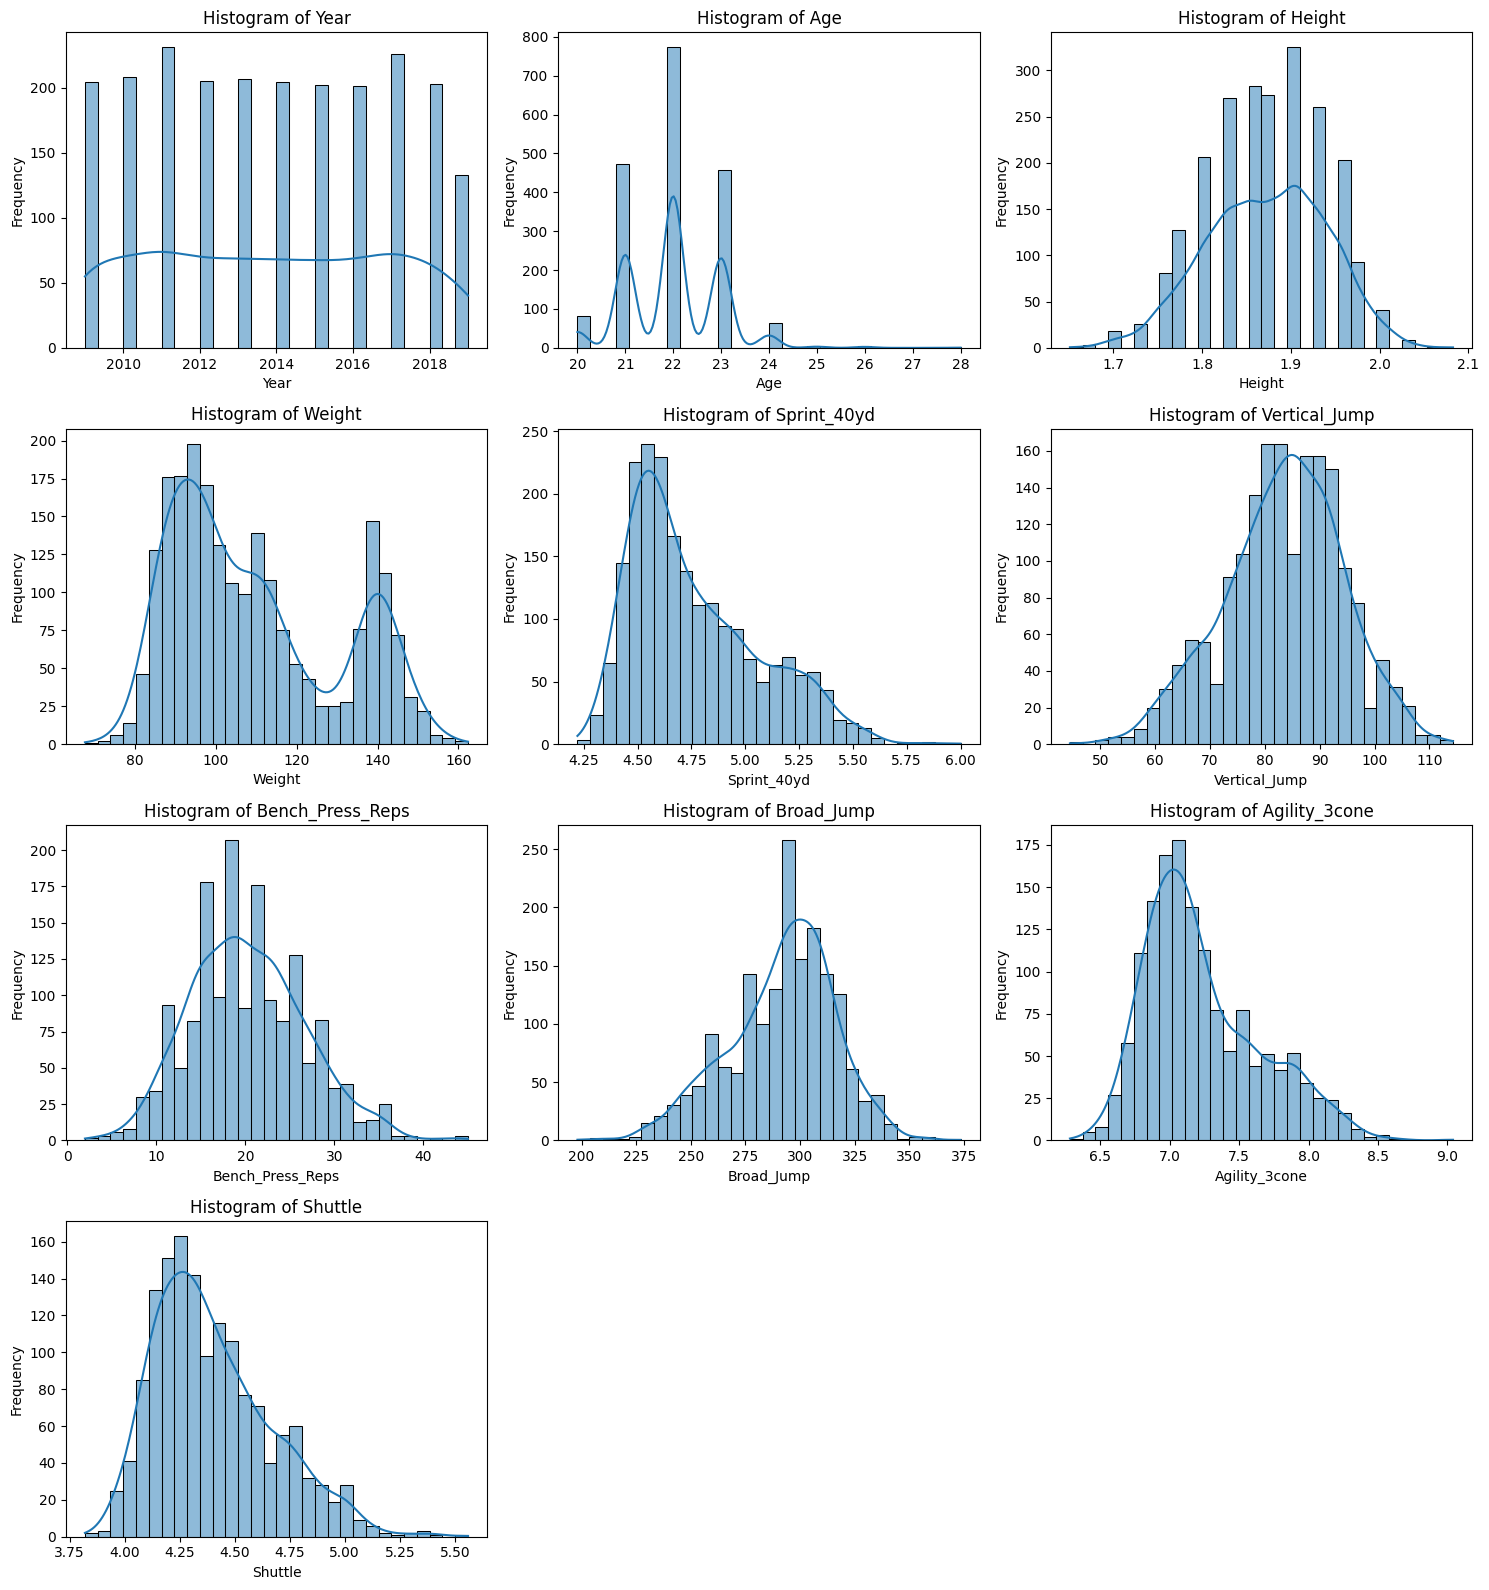

In [1501]:
num_cols = len(numeric_cols)
cols = 3
rows = (num_cols + cols-1) //cols
plt.figure(figsize=(5*cols,4*rows))

for i,col in enumerate(numeric_cols,1):
  plt.subplot(rows,cols,i)
  sns.histplot(X_train[col],bins=30,edgecolor='black',kde=True)
  plt.title(f"Histogram of {col}")
  plt.xlabel(col)
  plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

#weight is an intersteing column as it is bimodal, which works best with tree based algorithms and sucks for linear models, also filling with mean and median is not good as mean and median are both in the valley between the two peaks so we should feature engineer a categorical column (light,heavey)

<Axes: >

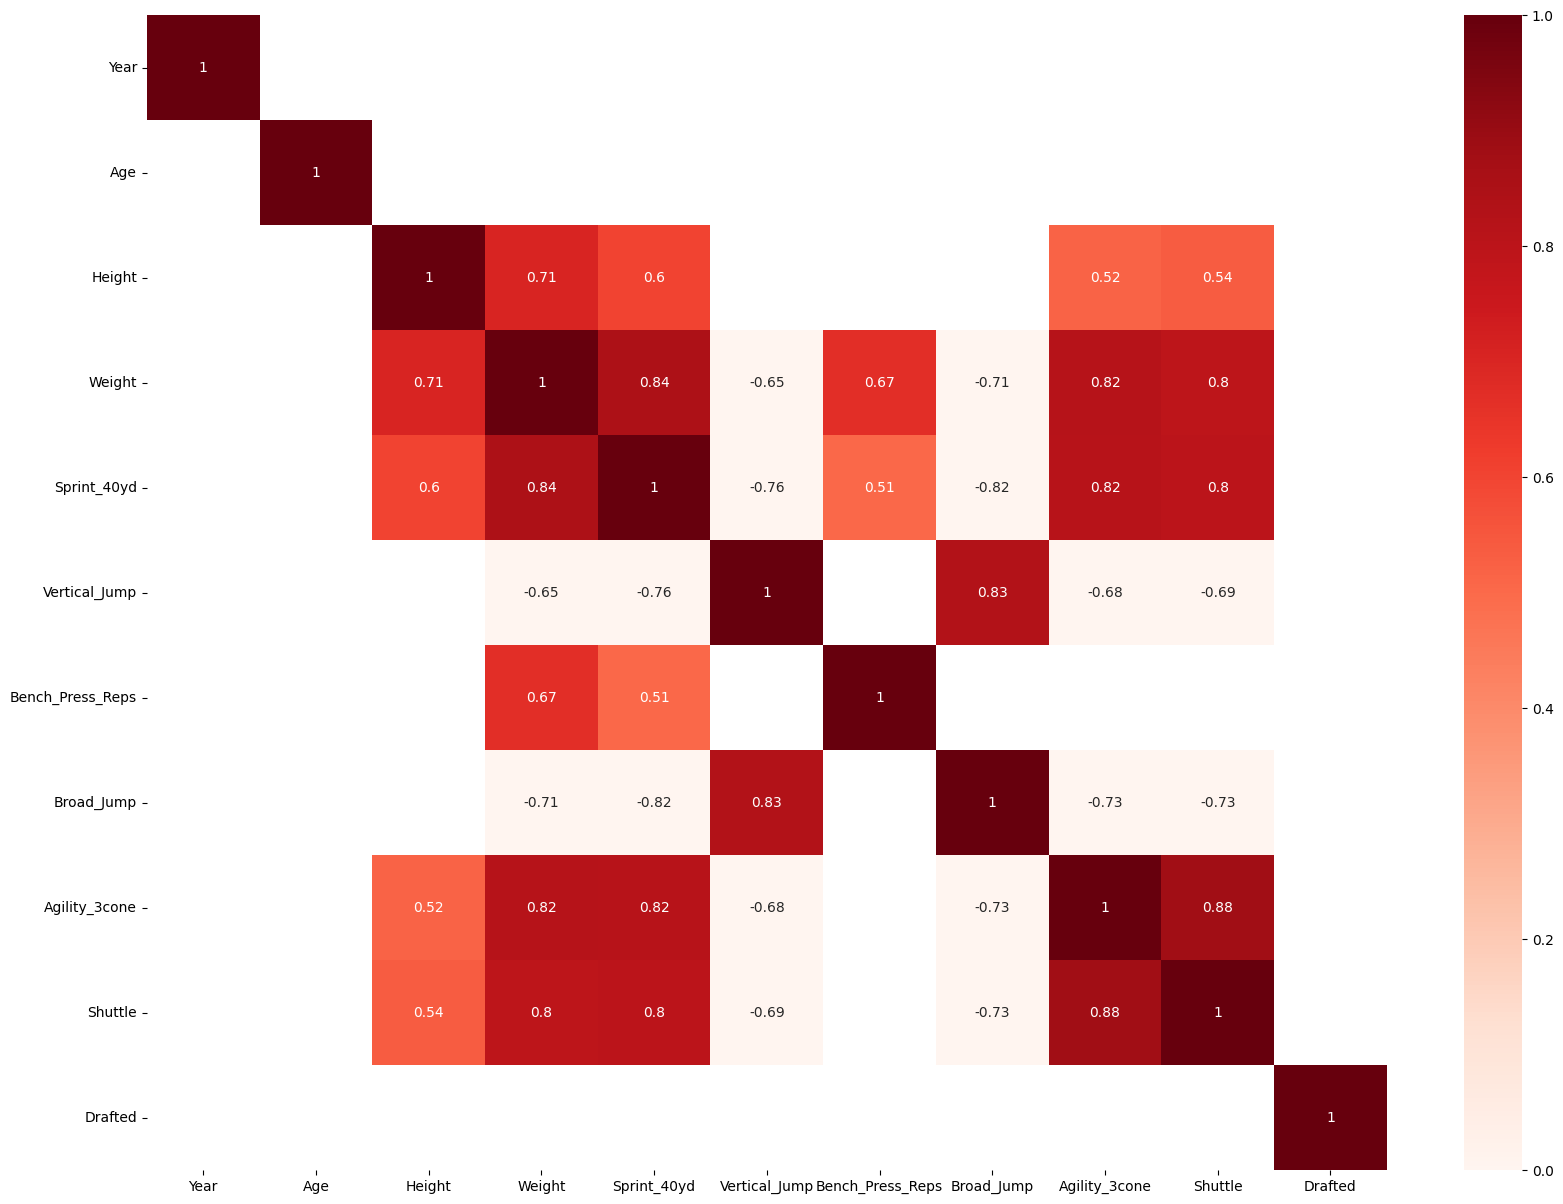

In [1502]:
corr = train_df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(20,15))
sns.heatmap(corr,annot=True,cmap='Reds',vmin=0,vmax=1,mask=corr.abs()<.5)
#should drop agility3cone or shuttle with linear models or maybe engineer them into one (agility3cone had more nulls)

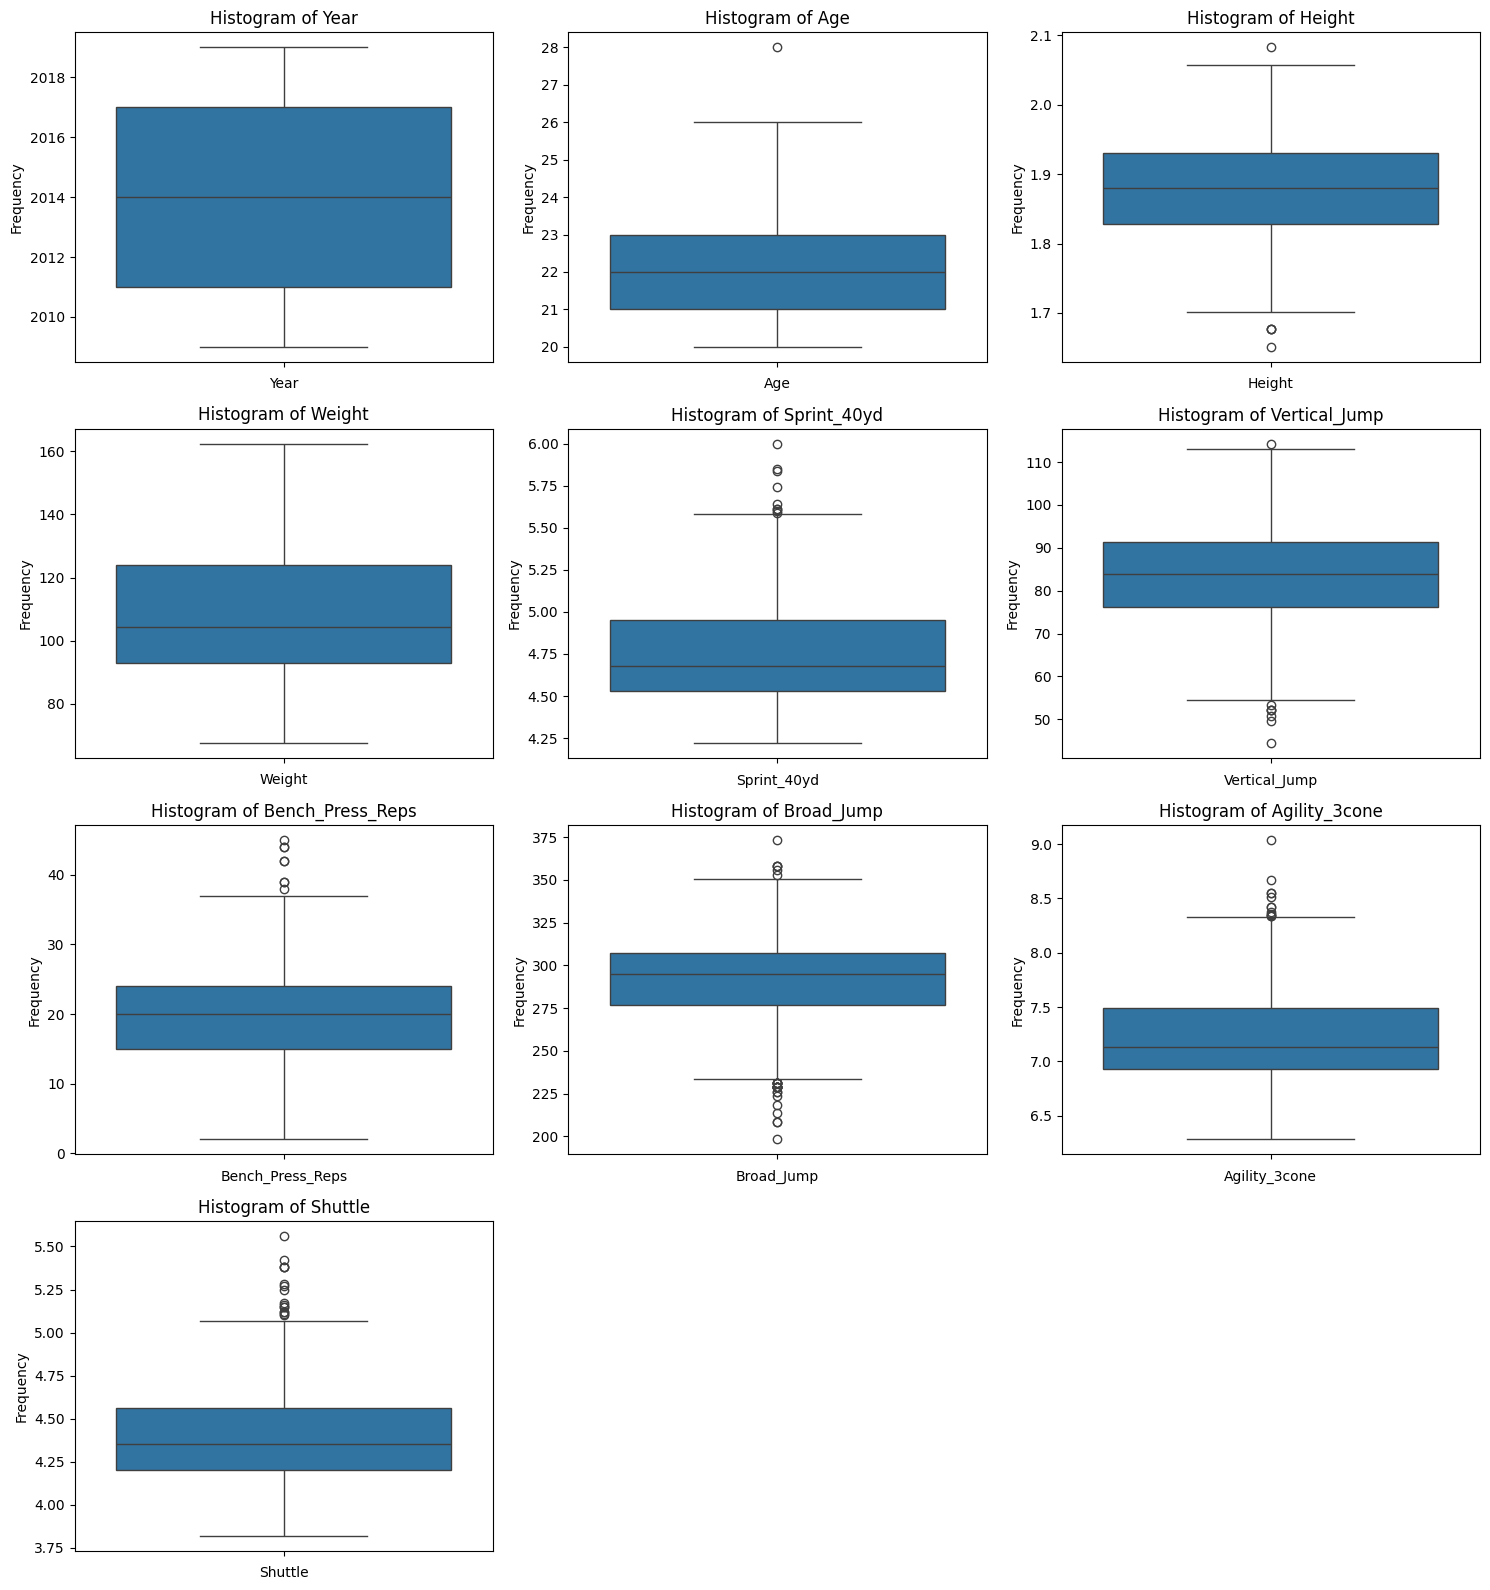

In [1503]:
plt.figure(figsize=(5*cols,4*rows))

for i,col in enumerate(numeric_cols,1):
  plt.subplot(rows,cols,i)
  sns.boxplot(X_train[col])
  plt.title(f"Histogram of {col}")
  plt.xlabel(col)
  plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [1504]:
categoric_cols = X_train.select_dtypes(include=['object']).columns
categoric_cols = list(categoric_cols)
categoric_cols

['School', 'Player_Type', 'Position_Type', 'Position']

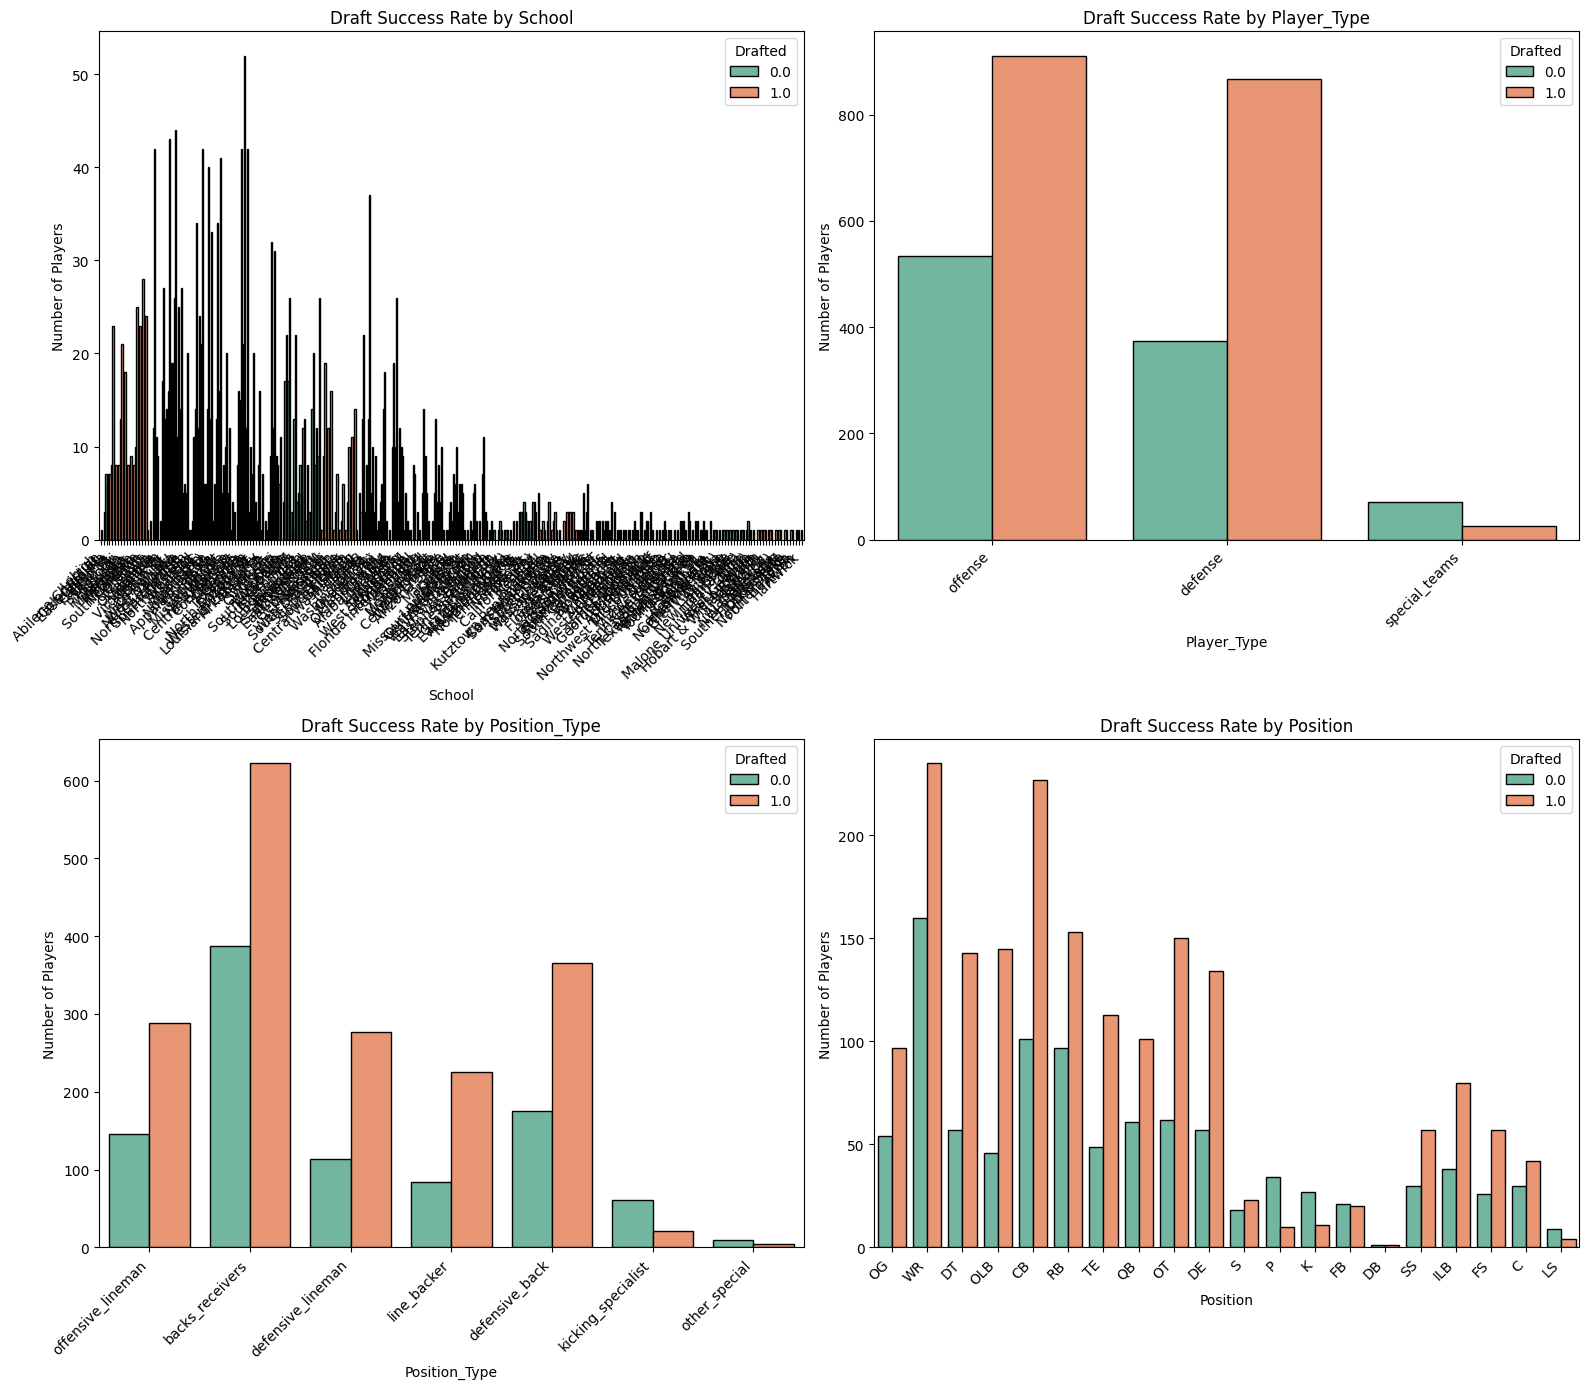

In [1505]:
cat_cols = len(categoric_cols)
cols = 2
rows = (cat_cols+cols-1) //cols
plt.figure(figsize=(8*cols,7*rows))

for i,col in enumerate(categoric_cols,1):
  plt.subplot(rows,cols,i)
  sns.countplot(data=train_df,x=col,hue='Drafted',edgecolor='black',palette='Set2')
  plt.title(f'Draft Success Rate by {col}')
  plt.xlabel(col)
  plt.ylabel('Number of Players')

  plt.xticks(rotation=45, ha='right')


plt.tight_layout()
plt.show()

In [1566]:
school_stats = train_df.groupby('School')['Drafted'].agg(['mean', 'count'])
print(school_stats.sort_values('count', ascending=False).head(50))

                        mean  count
School                             
Alabama             0.712329     73
LSU                 0.628571     70
USC                 0.666667     63
Ohio St.            0.728814     59
Florida St.         0.719298     57
Clemson             0.736842     57
Georgia             0.777778     54
Oklahoma            0.777778     54
Miami (FL)          0.740741     54
Florida             0.740000     50
Stanford            0.708333     48
Iowa                0.723404     47
Notre Dame          0.717391     46
Virginia Tech       0.613636     44
Penn St.            0.720930     43
Wisconsin           0.604651     43
UCLA                0.780488     41
Oregon              0.585366     41
North Carolina      0.658537     41
South Carolina      0.700000     40
Auburn              0.564103     39
Michigan St.        0.500000     38
Utah                0.722222     36
West Virginia       0.694444     36
Arkansas            0.666667     36
Washington          0.742857

count    85.000000
mean      0.645529
std       0.104307
min       0.357143
25%       0.588235
50%       0.666667
75%       0.722222
max       0.846154
Name: mean, dtype: float64
(0.356, 0.455]     4
(0.455, 0.553]    13
(0.553, 0.651]    20
(0.651, 0.748]    38
(0.748, 0.846]    10
Name: count, dtype: int64


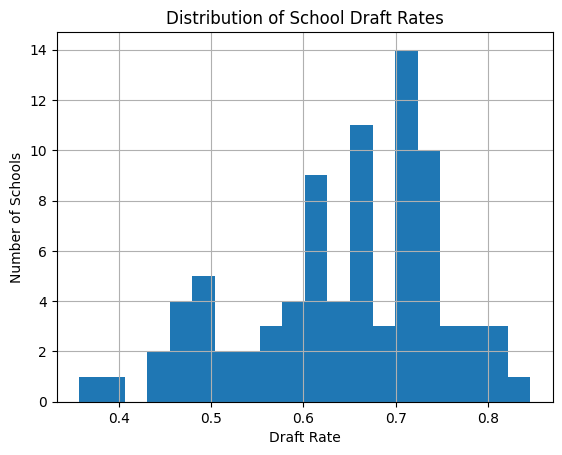

In [1611]:
stats = train_df.groupby('School')['Drafted'].agg(['mean','count'])
reliable = stats[stats['count'] >= 10]

# See the distribution of draft rates
print(reliable['mean'].describe())
print(reliable['mean'].value_counts(bins=5).sort_index())

# Plot it
reliable['mean'].hist(bins=20)
plt.xlabel('Draft Rate')
plt.ylabel('Number of Schools')
plt.title('Distribution of School Draft Rates')
plt.show()

# __5.Preprocessing__

## Handling missing values

In [1506]:
X_train[X_train['Age'].isna()]['Year'].value_counts() #MAR

,count
Year,
2018,58
2019,46
2015,41
2009,40
2010,38
2012,27
2016,26
2013,25
2017,24


In [1507]:
train_df[train_df['Sprint_40yd'].isna()]['Position'].value_counts() #MNAR

,count
Position,
WR,23
OT,13
RB,12
CB,10
TE,10
K,10
QB,9
S,9
ILB,9


In [1508]:
train_df[train_df['Vertical_Jump'].isna()]['Position'].value_counts() #MNAR

,count
Position,
WR,59
CB,58
TE,45
DT,38
P,37
OLB,37
K,37
OT,36
RB,35


In [1509]:
train_df[train_df['Bench_Press_Reps'].isna()]['Position'].value_counts() #MNAR

,count
Position,
QB,153
WR,88
CB,60
DE,44
P,40
OLB,39
DT,39
OT,39
TE,37


In [1510]:
train_df[train_df['Broad_Jump'].isna()]['Position'].value_counts() #MAR

,count
Position,
WR,66
CB,57
TE,49
DT,44
RB,44
OT,43
P,38
DE,36
K,36


# __6.Feature engineering__

In [1657]:
drill_cols = [
    'Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle'
]
drill_cols_cat = [
     'Weight'
]

class PosZscoreTransformer(BaseEstimator, TransformerMixin):

  def __init__(self, cols):
    self.cols = cols


  def fit(self, X, y=None):
    self.means_ = {}
    self.stds_ = {}

    for col in self.cols:
      self.means_[col] = X.groupby('Position')[col].mean()
      self.stds_[col] = X.groupby('Position')[col].std()

    return self

  def transform(self, X):
    X = X.copy()

    for col in self.cols:
      mean = X['Position'].map(self.means_[col])
      std = X['Position'].map(self.stds_[col])

      X[f"{col}_zscore"] = (X[col] - mean) / std
      X[f"{col}_zscore"] = X[f"{col}_zscore"].fillna(0)

      return X

In [1512]:
class AgeDeviationCalc(BaseEstimator, TransformerMixin):
  def fit(self, X, y=None):
    self.age_means_ = X.groupby('Position')['Age'].mean()
    return self

  def transform(self, X):
    X = X.copy()
    X['Age_Deviation'] = X['Age'] - X['Position'].map(self.age_means_)
    return X

In [1513]:
class SmoothedTargetEncoder(BaseEstimator, TransformerMixin):

  def __init__(self, col, weight):
    self.col = col
    self.weight = weight

  def fit(self, X, y):
    X = X.copy()
    X['__target__'] = y.values

    self.global_mean_ = y.mean()
    stats = X.groupby(self.col)['__target__'].agg(['mean','count'])

    stats['smoothed'] = (
        (stats['mean'] * stats['count']) + (self.global_mean_ * self.weight)
    ) / (stats['count'] + self.weight)
    self.smoothed_map_ = stats['smoothed']
    return self

  def transform(self, X):
    X = X.copy()
    X[f"{self.col}_draft_prop"] = (
        X[self.col]
        .map(self.smoothed_map_)
        .fillna(self.global_mean_)
    )
    return X

In [1533]:
class YearTargetEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y):
        X = X.copy()
        X['__target__'] = y.values
        self.year_means_ = X.groupby('Year')['__target__'].mean()
        self.global_mean_ = y.mean()
        return self

    def transform(self, X):
        X = X.copy()
        X['Year_draft_rate'] = (X['Year']
                                .map(self.year_means_)
                                .fillna(self.global_mean_))
        return X

In [1534]:
class PositionYearEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y):
        X = X.copy()
        X['__target__'] = y.values
        self.means_ = X.groupby(['Position', 'Year'])['__target__'].mean()
        self.global_mean_ = y.mean()
        return self

    def transform(self, X):
        X = X.copy()
        X['Position_Year_rate'] = (X.set_index(['Position', 'Year'])
                                    .index.map(self.means_)
                                    .fillna(self.global_mean_))
        return X

In [1613]:
class TopSchoolFlagTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, min_players=10):
        self.min_players = min_players

    def fit(self, X, y):
        X = X.copy()
        X['__target__'] = y.values

        stats = X.groupby('School')['__target__'].agg(['mean', 'count'])

        # Only trust schools with enough players
        self.reliable_stats_ = stats[stats['count'] >= self.min_players]['mean']
        self.global_mean_    = y.mean()

        return self

    def transform(self, X):
        X = X.copy()

        def get_tier(school):
            if school not in self.reliable_stats_.index:
                return 'unknown'                          # unseen or too few players
            rate = self.reliable_stats_.loc[school]
            if   rate >= 0.722: return 'elite'
            elif rate >= 0.667: return 'strong'
            elif rate >= 0.588: return 'average'
            else:              return 'weak'

        X['school_tier'] = X['School'].apply(get_tier)

        return X

In [1514]:
has_nulls = ['Vertical_Jump','Broad_Jump','Shuttle','Bench_Press_Reps','Agility_3cone'] #drop 'Sprint_40yd'
has_nulls_cat = ['Vertical_Jump','Broad_Jump','Shuttle','Bench_Press_Reps','Agility_3cone']
def add_missing(X, cols):
  for col in cols:
    X[f"{col}_missing"] = X[col].isna().astype(int)

  return X


In [1636]:
def add_athletic_features(X :pd.DataFrame ) :
  X['Total_Explosion_Score'] = X['Vertical_Jump'] + X['Broad_Jump']
  X['Speed_Score'] = (X['Weight'] * 200) / (X['Sprint_40yd'] ** 4)
  X['BMI'] = X['Weight'] / (X['Height']/100)**2
  X['Youth_Speed'] = (1 / X['Age']) * X['Speed_Score']
  X['Age_Speed_interaction'] = X['Age'] * X['Sprint_40yd']
  X['Youth_Explosion'] = (1 / X['Age']) * X['Total_Explosion_Score']
  return X

In [1517]:
def cast_to_category(X, cols):
  X = X.copy()
  X[cols] = X[cols].astype('category')
  return X

In [1575]:
cols_to_drop = ['Player_Type','Year','Height','Weight']
cols_to_drop_wthout_cat = ['Year','Height','Weight','BMI','Position_Type','School']
def drop_neg_features(X,cols):
  X = X.drop(cols,axis=1)
  return X

In [1519]:
X_train.columns

Index(['Year', 'Age', 'School', 'Height', 'Weight', 'Sprint_40yd',
       'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone',
       'Shuttle', 'Player_Type', 'Position_Type', 'Position'],
      dtype='object')

# __7.Model Training__

## XGBoost

In [ ]:
# pipe_xg = Pipeline([
#     ('zscore', PosZscoreTransformer(cols = drill_cols)),
#     ('ageDev', AgeDeviationCalc()),
#     # ('smoothed', SmoothedTargetEncoder(col="School",weight=15)), #dropping increased roc_auc
#     ('missing', FunctionTransformer(add_missing, kw_args={'cols': has_nulls})),
#     ('athletic', FunctionTransformer(add_athletic_features)),
#     ('cast_cats', FunctionTransformer(cast_to_category, kw_args={'cols': categoric_cols})),
#     ('drop_cols', FunctionTransformer(drop_neg_features, kw_args={'cols': cols_to_drop})),
#     ('clf',XGBClassifier(enable_categorical=True,random_state=42,colsample_bytree=.4,tree_method='hist',auto_class_weights='balanced'))
# ])

In [ ]:
# cv_xg = cross_val_score(pipe_xg,X_train,y_train,cv=10,scoring='roc_auc')

In [ ]:
# display(cv_xg,cv_xg.mean())

In [ ]:
# pipe_xg.fit(X_train,y_train)
# xgb_model = pipe_xg.named_steps['clf']
# importances = pd.Series(
#     xgb_model.feature_importances_,
#     index=xgb_model.feature_names_in_
# )
# plt.figure(figsize=(10, 8))
# importances.sort_values(ascending=True).plot(kind='barh', color='teal')
# plt.title('XGBoost Built-in Feature Importance (Top 20)')
# plt.xlabel('Importance (Gini / Gain)')
# plt.ylabel('Engineered Features')
# plt.tight_layout()
# plt.show()

In [ ]:
# X_valid_transformed = pipe_xg[:-1].transform(X_valid)
# result_engineered = permutation_importance(
#     pipe_xg.named_steps['clf'],
#     X_valid_transformed,
#     y_valid,
#     n_repeats=10,      # Shuffles each column 10 times for a stable average
#     random_state=42,
#     scoring='roc_auc'  # Use the same metric you care about!
# )
# perm_importances_eng = pd.Series(
#     result_engineered.importances_mean,
#     index=X_valid_transformed.columns
# )

# plt.figure(figsize=(10, 8))
# perm_importances_eng.sort_values(ascending=True).tail(20).plot(kind='barh', color='coral')
# plt.title('Permutation Importance: Engineered Features (Validation Data)')
# plt.xlabel('Mean Drop in ROC AUC')
# plt.tight_layout()
# plt.show()

## CatBoost

In [1658]:
categoric_cols = [ 'Player_Type', 'Position']
print(categoric_cols)

['Player_Type', 'Position']


In [1663]:
pipe_cat = Pipeline([
    #('ageDev', AgeDeviationCalc()),
    ('athletic', FunctionTransformer(add_athletic_features)),
    ('year', YearTargetEncoder()),
    ('zscore', PosZscoreTransformer(cols = drill_cols_cat)),
    # ('Schoolflag', TopSchoolFlagTransformer(min_players=10)),
    ('drop_cols', FunctionTransformer(drop_neg_features, kw_args={'cols': cols_to_drop_wthout_cat})),
    ('clf',CatBoostClassifier(random_state=42,verbose=0))
])

In [1664]:
cv_cat = cross_val_score(pipe_cat,X_train,y_train,cv=10,scoring='roc_auc',params={'clf__cat_features': categoric_cols})

In [1665]:
display(cv_cat,cv_cat.mean())

array([0.82498242, 0.90005274, 0.82882405, 0.85366932, 0.78926282,
       0.8005698 , 0.85888533, 0.83342236, 0.83146368, 0.84170228])

np.float64(0.8362834798250557)

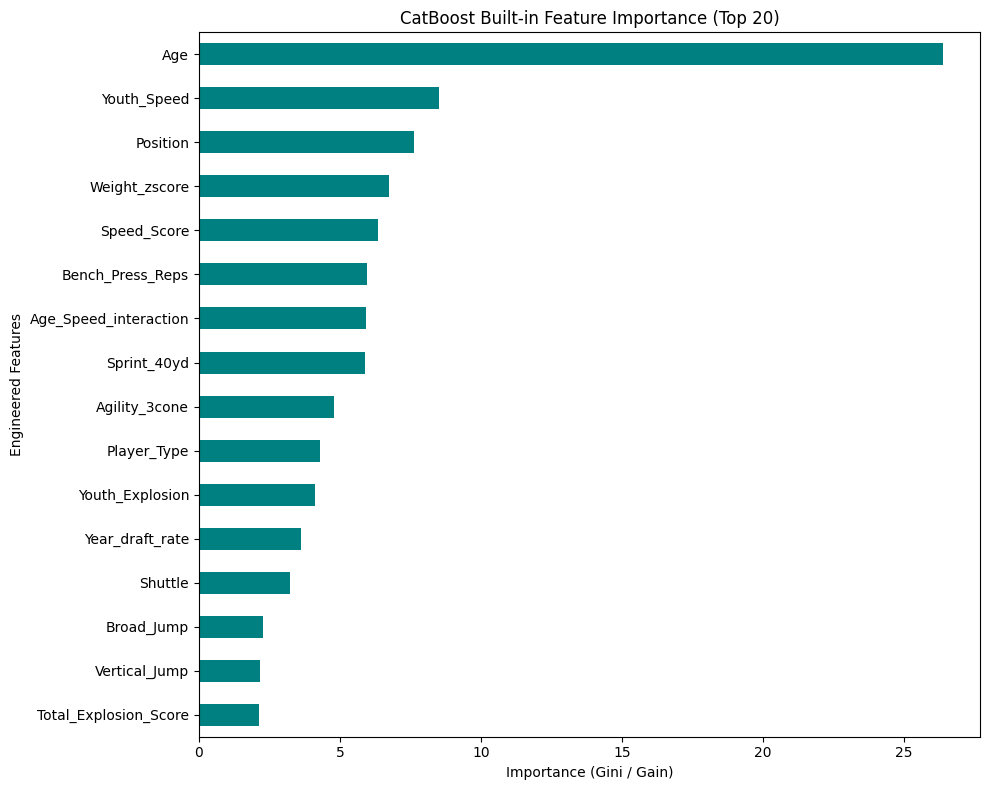

In [1666]:
pipe_cat.fit(X_train,y_train,clf__cat_features=categoric_cols)
cat_model = pipe_cat.named_steps['clf']
importances = pd.Series(
    cat_model.feature_importances_,
    index=cat_model.feature_names_
)
plt.figure(figsize=(10, 8))
importances.sort_values(ascending=True).plot(kind='barh', color='teal')
plt.title('CatBoost Built-in Feature Importance (Top 20)')
plt.xlabel('Importance (Gini / Gain)')
plt.ylabel('Engineered Features')
plt.tight_layout()
plt.show()

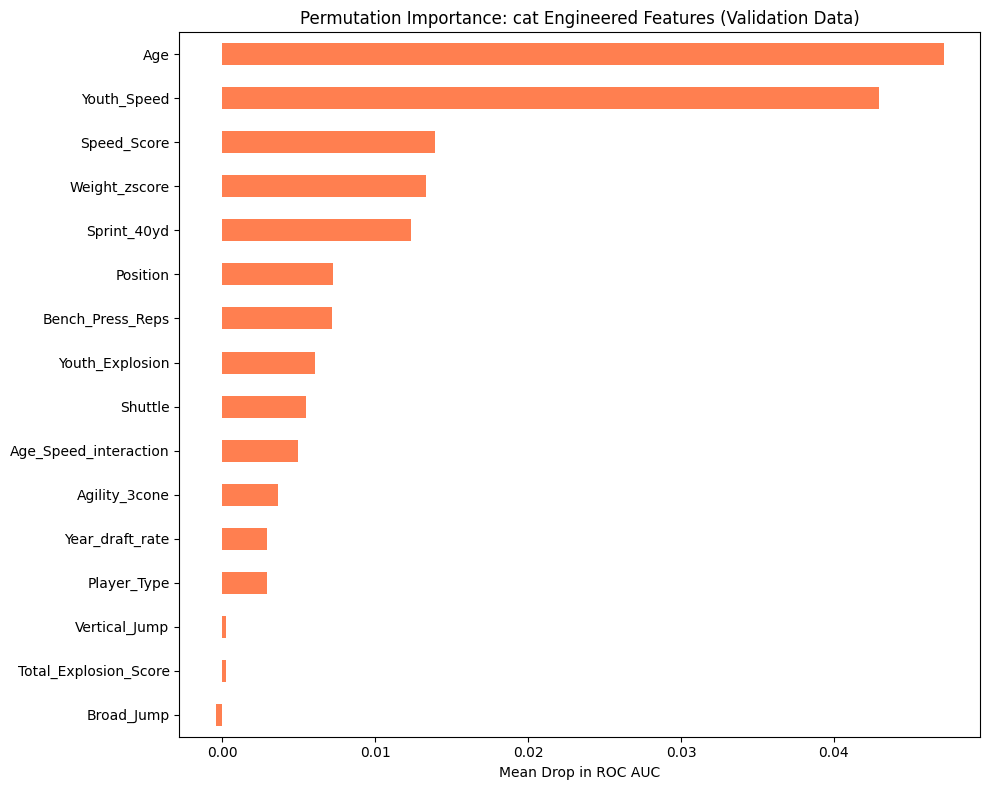

In [1667]:
X_valid_transformed = pipe_cat[:-1].transform(X_valid)
result_engineered = permutation_importance(
    pipe_cat.named_steps['clf'],
    X_valid_transformed,
    y_valid,
    n_repeats=10,      # Shuffles each column 10 times for a stable average
    random_state=42,
    scoring='roc_auc'  # Use the same metric you care about!
)
perm_importances_eng = pd.Series(
    result_engineered.importances_mean,
    index=X_valid_transformed.columns
)

plt.figure(figsize=(10, 8))
perm_importances_eng.sort_values(ascending=True).tail(20).plot(kind='barh', color='coral')
plt.title('Permutation Importance: cat Engineered Features (Validation Data)')
plt.xlabel('Mean Drop in ROC AUC')
plt.tight_layout()
plt.show()

## optuna

In [ ]:
# groups = X_train_internal['Year']

# def objective(trial):
#   param = {
#        'enable_categorical': True,
#         'tree_method': 'hist',
#         'objective': 'binary:logistic',
#         'eval_metric': 'auc',
#         'max_depth': trial.suggest_int('max_depth', 3, 9),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
#         'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 10)
#   }

#   sgkf = StratifiedGroupKFold(n_splits=5)

#   cv_scores = []

#   for train_idx, valid_idx in sgkf.split(X_train_internal, y_train_internal, groups=groups):

#         # Split the data based on the fold indices
#         X_train_fold, X_valid_fold = X_train_internal.iloc[train_idx], X_train_internal.iloc[valid_idx]
#         y_train_fold, y_valid_fold = y_train_internal.iloc[train_idx], y_train_internal.iloc[valid_idx]

#         # Initialize the model for this specific fold
#         model = XGBClassifier(**param)

#         # Fit with early stopping to prevent wasting time on bad trees
#         model.fit(
#             X_train_fold, y_train_fold,
#             eval_set=[(X_valid_fold, y_valid_fold)],
#             verbose=False
#         )

#         # Predict and calculate ROC-AUC for this fold
#         preds = model.predict_proba(X_valid_fold)[:, 1]
#         fold_auc = roc_auc_score(y_valid_fold, preds)

#         # Save the score
#         cv_scores.append(fold_auc)

#     # 4. Return the average ROC-AUC across all 5 folds
#   return np.mean(cv_scores)

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)

In [1677]:
optuna.logging.set_verbosity(optuna.logging.WARNING)



def objective(trial):
    params = {
        'iterations':          trial.suggest_int('iterations', 200, 800),
        'depth':               trial.suggest_int('depth', 3, 7),
        'learning_rate':       trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg':         trial.suggest_float('l2_leaf_reg', 1, 10),
        'colsample_bylevel':   trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'min_data_in_leaf':    trial.suggest_int('min_data_in_leaf', 1, 50),
        'random_strength':     trial.suggest_float('random_strength', 0, 5),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
    }

    cat_features=tuple(categoric_cols)
    pipe_cat = Pipeline([
    ('athletic', FunctionTransformer(add_athletic_features)),
    ('year', YearTargetEncoder()),
    ('zscore', PosZscoreTransformer(cols = drill_cols_cat)),
    ('drop_cols', FunctionTransformer(drop_neg_features, kw_args={'cols': cols_to_drop_wthout_cat})),
    ('clf',CatBoostClassifier(**params,cat_features=cat_features,early_stopping_rounds=50,random_state=42,verbose=0))
])

    scores = cross_val_score(pipe_cat, X_train, y_train, cv=5, scoring='roc_auc')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"Best AUC:    {study.best_value:.4f}")
print(f"Best Params: {study.best_params}")

  0%|          | 0/100 [00:00<?, ?it/s]

Best AUC:    0.8458
Best Params: {'iterations': 500, 'depth': 6, 'learning_rate': 0.01891641022186938, 'l2_leaf_reg': 3.8007902320148363, 'colsample_bylevel': 0.9080531360780953, 'min_data_in_leaf': 37, 'random_strength': 4.910001158375988, 'bagging_temperature': 0.7319146619147885}


In [1678]:
Best_Params = {'iterations': 500, 'depth': 6, 'learning_rate': 0.01891641022186938, 'l2_leaf_reg': 3.8007902320148363, 'colsample_bylevel': 0.9080531360780953, 'min_data_in_leaf': 37, 'random_strength': 4.910001158375988, 'bagging_temperature': 0.7319146619147885}

In [1681]:
best_pipe = Pipeline([
    ('zscore',   PosZscoreTransformer(cols=drill_cols)),
    ('ageDev',   AgeDeviationCalc()),
    ('smoothed', SmoothedTargetEncoder(col='School', weight=15)),
    ('missing',  FunctionTransformer(add_missing, kw_args={'cols': has_nulls})),
    ('athletic', FunctionTransformer(add_athletic_features)),
    ('drop_cols',FunctionTransformer(drop_neg_features, kw_args={'cols': cols_to_drop_wthout_cat})),
    ('clf',      CatBoostClassifier(
                     **study.best_params,
                     random_state=42,
                     verbose=0
                 ))
])
X_test_clean = X_test.drop('Id', axis=1)

best_pipe.fit(X_train, y_train,clf__cat_features=categoric_cols)
val_auc = roc_auc_score(y_valid, best_pipe.predict_proba(X_valid)[:, 1])
print(f"Val AUC: {val_auc:.4f}")

X_full = pd.concat([X_train, X_valid])
y_full = pd.concat([y_train, y_valid])
best_pipe.fit(X_full, y_full,clf__cat_features=categoric_cols)

test_preds = best_pipe.predict_proba(X_test_clean)[:, 1]

submission = pd.DataFrame({
    'Id':      X_test['Id'],
    'Drafted': test_preds
})

submission.to_csv('submission.csv', index=False)
print(submission.head())

Val AUC: 0.8002
     Id   Drafted
0  2781  0.653191
1  2782  0.828178
2  2783  0.946137
3  2784  0.937710
4  2785  0.868937
